# Deferred revenue front-runs the sales print. Can you trade it? 📥
### A SaaS balance-sheet signal that *genuinely* predicts next quarter's revenue — and that the market has already figured out

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads sales%3F: Confirmed](https://img.shields.io/badge/Leads_sales%3F-Confirmed-8b949e?style=flat-square)

Here's a signal with real accounting logic behind it. When a software company sells you an annual subscription, it can't book all that cash as revenue on day one — it parks it on the balance sheet as **deferred revenue** (a liability) and bleeds it into the income statement over the next four quarters. So a swelling deferred-revenue balance is, quite literally, *revenue that hasn't shown up yet*. The pitch writes itself: watch deferred-revenue growth, and you're seeing the future sales print early — so the stock should follow.

Half of that is dead right. The other half is where the money would be — and that's the half that doesn't work.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 40 subscription/SaaS-type US names that report a deferred-revenue balance on EDGAR, 2009→2026; a genuinely **thin, uneven panel** (the cross-section is single digits early on). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from deferred_revenue import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 40, 'n_events': 1238, 'end_lo': '2009-11-27', 'end_hi': '2026-04-30', 'fp_prices': 'f8a44ad79534', 'n_months': 195, 'avg_n': 19.6, 'ls_span_lo': '2010-04-30', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 56.2, 'ls_ann': 6.74, 'ls_t_iid': 1.04, 'ls_t_nw': 0.94, 'ls_sharpe': 0.26, 'ls_hit': 55, 'ls_long_bps': 230.3, 'ls_short_bps': 174.1, 'ls_turn': 0.1, 'ls_cum': 1.72, 'ls120_mean_bps': 50.8, 'ls120_t_nw': 0.84, 'scaled_mean_bps': 75.9, 'scaled_t_nw': 1.63, 'scaled_sharpe': 0.43, 'xsec_early': 8.8, 'xsec_late': 27.2, 'drift': {21: (1232, 1.25, 1.54, -0.29, -0.42, 48, 0.6676), 63: (1213, 5.7, 5.37, 0.33, 0.2, 49, 0.4062), 126: (1185, 10.15, 9.62, 0.53, 0.22, 47, 0.4096)}, 'mono63': (5.37, 5.12, 5.7), 'mono126': (9.62, 9.36, 10.15), 'era_early_n': 105, 'era_early_bps': 53.3, 'era_early_t': 0.86, 'era_late_n': 90, 'era_late_bps': 59.6, 'era_late_t': 0.55, 'ls_n': 917, 'ls_slope': 0.434, 'ls_reg_t': 27.05, 'ls_r2': 0.444, 'ls_corr': 0.667, 'ls_top_sales': 40.4, 'ls_bot_sales': 8.4, 'ls_spread': 32.0, 'contemp_corr': 0.678, 'net': {(10, 50): (49.9, 5.99, 0.83, 0.23), (20, 100): (43.7, 5.24, 0.73, 0.2)}, 'syn_null_mean': -0.35, 'syn_null_sd': 1.08, 'syn_null_fire': 1, 'syn_null_seeds': 12, 'syn_planted_bps': 236.8, 'syn_planted_t': 6.56}


real cache present: True | events: 1238 | names: 40


## The answer first

| Question | Answer |
|---|---|
| Does deferred-revenue growth predict future **sales**? | **Yes — strongly.** The names with the fastest-growing deferred revenue go on to grow next quarter's sales **+32 percentage points** faster than the slowest (correlation **+0.67**). The accounting lead is real and mechanical. |
| Does it predict future **returns**? | **Not in any way we can certify.** A long-short that buys high-deferred-growth names and shorts low ones earns a right-signed **+6.7%/yr** on paper — but the statistics say that's indistinguishable from luck (robust *t* = **+0.94**, the bar is 2). |
| Why the gap? | The lead is **public information**. Anyone can read the balance sheet; the market prices the coming revenue as soon as the 10-Q lands. A real signal about the *business* is not automatically a signal about the *stock*. |
| Can you trade it? | **No.** The return edge doesn't clear the bar even before costs — there's nothing to charge costs against. |

> Real information about the company. No alpha in the stock. That distinction is the whole study.

## 1 · The claim

> *"Deferred revenue is bookings that haven't hit the income statement yet. If it's growing, revenue is coming — so buy the names whose deferred revenue is swelling fastest."*

It's a specific case of a respectable academic idea — the market misprices the *accrual* pieces of earnings (Sloan 1996). Deferred revenue is an unusually clean, *good-news* accrual: unlike most accruals it doesn't reverse against future earnings, it **becomes** them. The question is whether that accounting lead is also a *trading* lead.

## 2 · So what?

If a plain balance-sheet line predicted stock returns, it would be one of the easiest anomalies going — no estimates feed, no alt-data, just one number in every 10-Q. That's exactly why it deserves suspicion: it's *too* readable. Everyone with a brokerage account can pull deferred revenue. If markets price public information at all, this is the kind they should price fastest.

## 3 · How would we even know?

- **The signal.** For each of 40 subscription-type names, year-over-year growth in the current deferred-revenue balance, known only on the **filing date** of the 10-Q/10-K (never before — no peeking at a number that isn't public yet).
- **The sales test.** Does this quarter's deferred-revenue growth predict *next* quarter's revenue growth? (The accounting claim.)
- **The return test.** Each month, rank the names on the signal, buy the top third, short the bottom third, and hold for the next month. Does the spread make money — and can we tell it apart from noise?
- **The mirage check.** If the return spread can't beat a coin-flip relabelling of the names, it's not a signal, however good the story sounds.

## 4 · The teardown — let's actually look

**First, the part that works: does deferred revenue really lead sales?** For every filing we line up this quarter's deferred-revenue growth against the *next* quarter's actual revenue growth, and split the names into thirds.

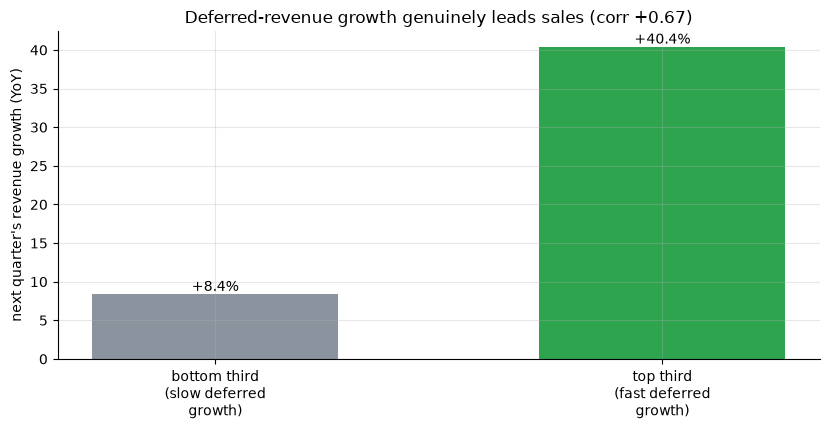

future sales growth: top third +40.4% vs bottom third +8.4% -> spread +32.0 pp, correlation +0.67


In [2]:
if HAVE_REAL:
    q = st.leads_sales(EV)
    top, bot, corr = q['top_sales']*100, q['bot_sales']*100, q['corr']
else:
    top, bot, corr = R['ls_top_sales'], R['ls_bot_sales'], R['ls_corr']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['bottom third\n(slow deferred\ngrowth)','top third\n(fast deferred\ngrowth)'],
       [bot, top], color=[GREY, GREEN], width=.55)
for i,v in enumerate([bot, top]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel("next quarter's revenue growth (YoY)")
ax.set_title(f'Deferred-revenue growth genuinely leads sales (corr {corr:+.2f})')
plt.tight_layout(); plt.show()
print(f'future sales growth: top third {top:+.1f}% vs bottom third {bot:+.1f}% '
      f'-> spread {top-bot:+.1f} pp, correlation {corr:+.2f}')

That's a **+32 percentage-point** gap in *future* sales growth between the fastest- and slowest-deferred-growth names, correlation **+0.67**. The accounting lead is not folklore — it's about as real as a cross-sectional signal gets. Deferred revenue really is next year's revenue, sitting on the balance sheet in plain sight.

**So now the money question: do the stocks follow?** Same ranking, but instead of future sales we measure the forward *return* of a buy-the-top-third, short-the-bottom-third portfolio.

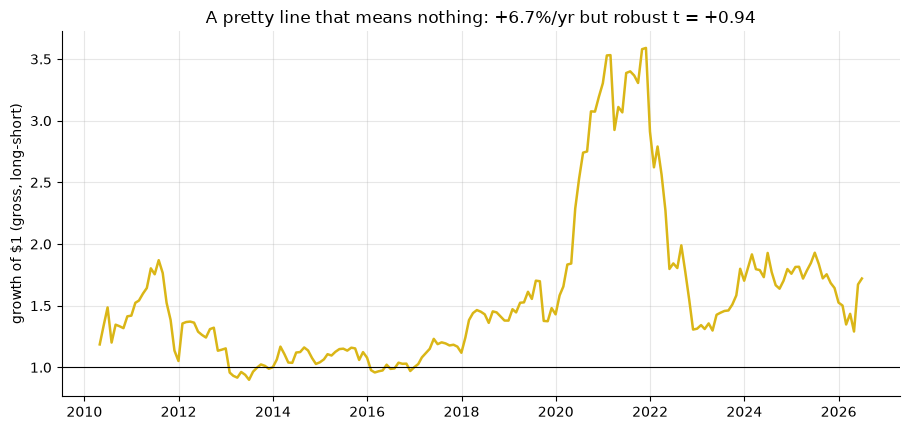

long-short: +6.7%/yr gross, but Newey-West t = +0.94 (the bar is 2)


In [3]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='defrev_yoy', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ann, tnw = s['ann_pct'], s['t_nw']
    cum = (1+ls['ls']).cumprod()
else:
    ann, tnw = R['ls_ann'], R['ls_t_nw']
    cum = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if cum is not None:
    ax.plot(cum.index, cum.values, color=AMBER, lw=1.8)
    ax.axhline(1.0, c='k', lw=.8)
    ax.set_ylabel('growth of $1 (gross, long-short)')
    ax.set_title(f'A pretty line that means nothing: +{ann:.1f}%/yr but robust t = {tnw:+.2f}')
else:
    ax.text(.5,.5,'run with cache for the equity curve',ha='center'); ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f'long-short: +{ann:.1f}%/yr gross, but Newey-West t = {tnw:+.2f} (the bar is 2)')

It *slopes up* — **+6.7%/yr** gross, growing \$1 to \$1.72 over 195 months. Tempting! But that's the trap. Once you account for how noisy and bunchy those monthly returns are, the robust *t*-statistic is **+0.94** — nowhere near the **2** we require to call something real. A line that drifts up and a *reliable* edge are different things, and this is the former.

**The tell:** if the signal really sorted returns, the middle third should land between the top and bottom. It doesn't — the thirds are essentially tied.

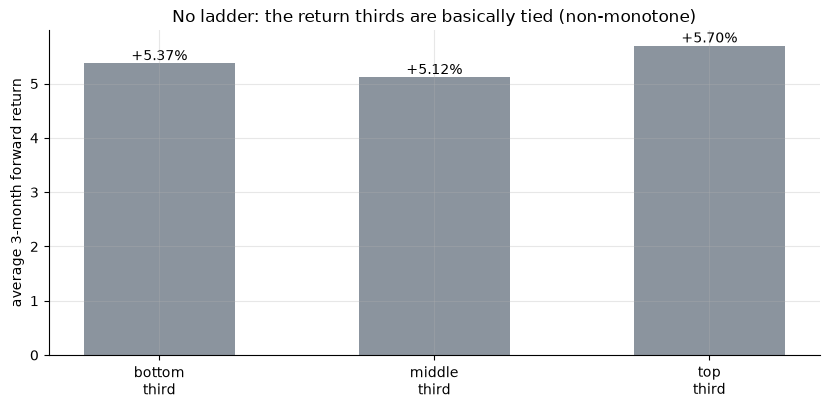

3-month forward return by deferred-growth third (low->high): ['+5.37%', '+5.12%', '+5.70%']


In [4]:
if HAVE_REAL:
    fr = st.event_drift_frame(PX, EV, horizon=63)
    mono = st.bucket_means(fr, 3)*100
else:
    mono = np.array(R['mono63'])
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(['bottom\nthird','middle\nthird','top\nthird'], mono,
       color=[GREY, GREY, GREY], width=.55)
for i,v in enumerate(mono): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average 3-month forward return')
ax.set_title('No ladder: the return thirds are basically tied (non-monotone)')
plt.tight_layout(); plt.show()
print('3-month forward return by deferred-growth third (low->high):', [f'{v:+.2f}%' for v in mono])

No staircase. The fastest-deferred-growth third doesn't reliably out-return the slowest over the next quarter — the bars wobble instead of climbing. Compare that to the *sales* chart above, which is a clean, monotone lead. Same signal, two totally different answers: it forecasts the **business**, not the **stock**.

## 5 · The verdict

- **Does it lead sales? — Confirmed.** +32 pp of future sales growth between top and bottom thirds, correlation +0.67. Real, mechanical, not in dispute.
- **Signal (returns) — Weak.** The return spread is right-signed and ~+6.7%/yr on paper, but it never clears the significance bar (robust *t* = +0.94) and the thirds don't form a ladder. There's a whiff of the effect the literature describes, but this tape can't certify it.
- **Tradability — Mirage.** You can't get paid for an edge you can't distinguish from luck. It fails before costs are even charged.

> The honest one-liner: *deferred revenue tells you where the company is going, and the market already knows.*

## 6 · Going further 🚪

- **Where an edge might still hide.** Not in the *level* of the public number, but maybe in the *surprise* — deferred-revenue growth vs what a naïve model would expect — or in the gap between deferred-revenue growth and the growth analysts are modelling. That's the residual this study didn't chase.
- **The coverage caveat is real.** Early in the sample only a handful of names reported the concept (the cross-section grows from ≈9 names in 2010 to ≈27 by the mid-2020s). A wider, deeper panel might sharpen the return test — though the flatness of the event-drift makes a hidden edge unlikely.
- **Sibling studies:** [199-sales-growth](../../199-sales-growth/) (ranks on the *recognised* top line), [534-revenue-surprise-drift](../../534-revenue-surprise-drift/) (the drift after a *revenue surprise*), and [799-order-backlog-drift](../../799-order-backlog-drift/) (order backlog / RPO, one step earlier in the cash cycle). See [docs/references.md](docs/references.md) for the exact dedup.

*Think the alpha is in the surprise, not the level? Build the expectation model, show a certifiable net spread on the size you'd actually run — then we'll talk.*